# 0 · Headline  `[EVAL]`

The 3 canonical thesis figures, regenerated into `results/`. Thin and figure-only — the full analysis is in `1`-`6`. **PTO** (preference-tree -> DPO) vs **GRPO**, matched look-ahead K; *arm* = one (method x K) run, *iteration* 0 = untrained base. Everything here is full-conversation eval (the held-out outcome), never the training reward.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 1 · Outcomes — pooled Base vs each arm's best  `[EVAL]`
**Purpose.** Per rubric, the pooled Base bar (all arms share the untrained policy) vs each arm's peak iteration; dotted line = base.

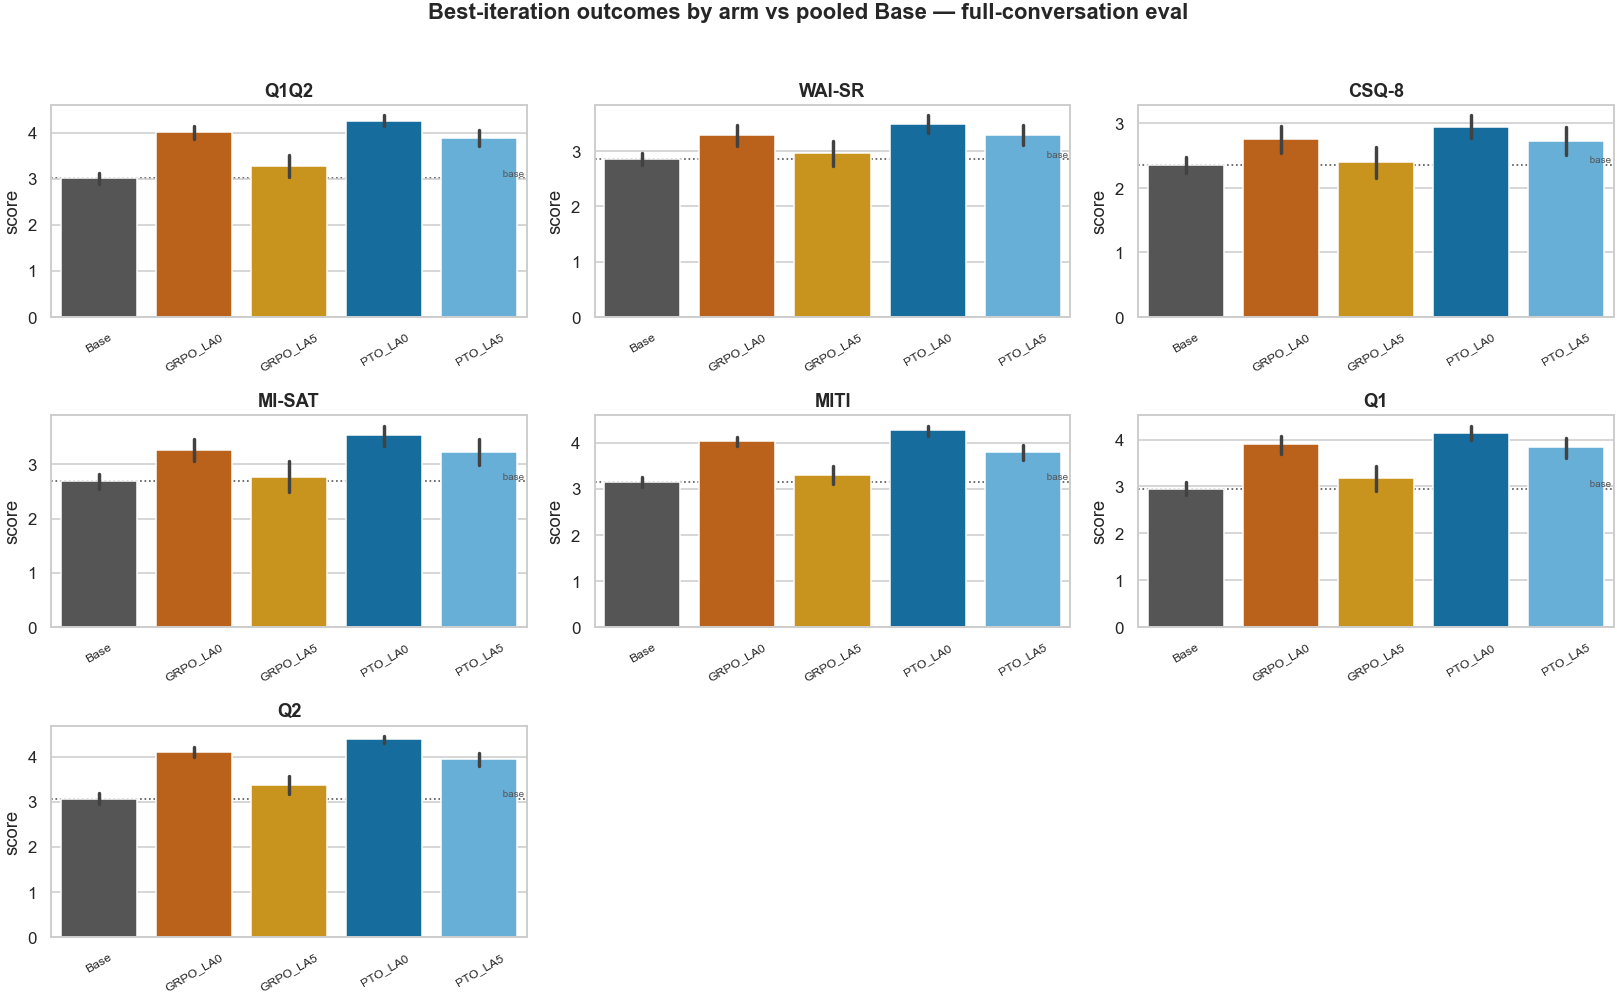

In [2]:
SEL, best = exp3.best_per_experiment(S.SCORES)
SEL_D = exp3.collapse_base(SEL)
fig = plots.outcomes_headline_by_arm(SEL_D, palette=figures.arm_palette(sorted(SEL_D.arm.unique())))
exp3.save_fig(fig, "outcomes_headline", caption="Pooled Base + each arm's best iteration (peak by own training oracle) across the MI rubrics; full-conversation eval, mean +/- 95% CI over 96 personas. Dotted line = base."); plt.show()

## 2 · Did it work? — effect vs base  `[EVAL]`
**Purpose.** The vs-base effect size per arm x rubric as a forest plot (Δ + 95% CI, dz labelled, colored by magnitude) — the readable stand-in for the big stats table (full table in `6`).

  [stats] dropping thin arms (<3 scored iters): ['GRPO_LA5']


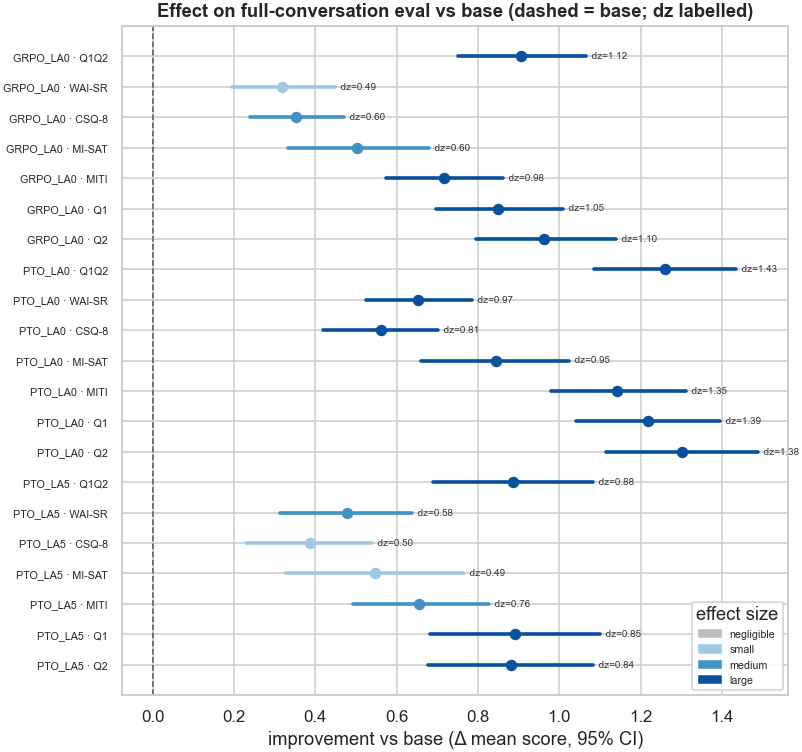

In [3]:
MR = stats.filter_thin_arms(stats.main_results_table(S.SCORES, target="final"), S.SCORES)
fig = plots.effect_forest(MR)
exp3.save_fig(fig, "effect_vs_base_forest", caption="Improvement vs base (Δ Q-mean + 95% CI) per arm x rubric, full-conversation eval; dot color = effect-size label, dz annotated. Dashed line = base."); plt.show()

## 3 · Primary learning curve (Q1+Q2)  `[EVAL]`
**Purpose.** The trained rubric across iterations, arms overlaid; grey band = oracle noise (~0.10) around base.

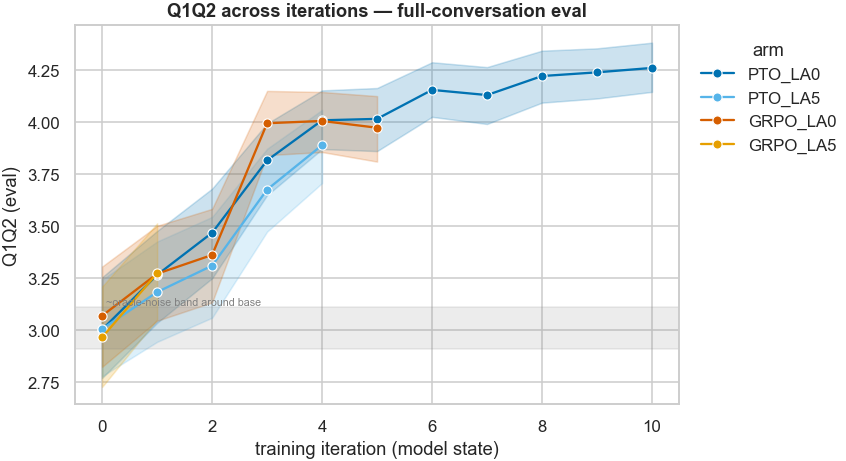

In [4]:
fig = plots.single_metric_trajectory(S.SCORES, "Q1Q2", palette=S.PALETTE, oracle_noise=S.ORACLE_NOISE)
exp3.save_fig(fig, "trajectory_Q1Q2", caption="Q1+Q2 mean across iterations per arm (mean +/- 95% CI, N=96). Grey band = oracle reproducibility (~0.10) around base."); plt.show()

## 4 · Artifact index
What `results/` now holds (figures already rendered above).

In [5]:
import glob
for sub, base, pat in [("figures", exp3.FIGURES_DIR, "*.pdf"), ("tables", exp3.TABLES_DIR, "*.md")]:
    files = sorted(os.path.basename(f) for f in glob.glob(os.path.join(base, pat)))
    print(f"=== results/{sub} ({len(files)}) ===")
    for f in files: print("  -", f)

=== results/figures (30) ===
  - GRPO_K0_vs_K5_Q1Q2.pdf
  - PTO_K0_vs_K5_Q1Q2.pdf
  - PTO_LA0_pref_category_drift.pdf
  - PTO_LA0_pref_word_drift.pdf
  - PTO_LA0_pref_word_ranking.pdf
  - PTO_LA5_pref_category_drift.pdf
  - PTO_LA5_pref_word_drift.pdf
  - PTO_LA5_pref_word_ranking.pdf
  - advantage_signal_sidebyside.pdf
  - behavior_drift.pdf
  - effect_vs_base_forest.pdf
  - faithfulness_proxy_vs_eval.pdf
  - heterogeneity_cooperation_level_GRPO_LA0.pdf
  - heterogeneity_cooperation_level_PTO_LA0.pdf
  - heterogeneity_cooperation_level_PTO_LA5.pdf
  - heterogeneity_problem_GRPO_LA0.pdf
  - heterogeneity_problem_PTO_LA0.pdf
  - heterogeneity_problem_PTO_LA5.pdf
  - method_contrast_Q1Q2_LA0.pdf
  - method_contrast_Q1Q2_LA5.pdf
  - outcomes_by_model.pdf
  - outcomes_headline.pdf
  - pref_category_drift.pdf
  - pref_word_drift.pdf
  - pref_word_ranking.pdf
  - reward_distribution_by_arm.pdf
  - rubric_correlation.pdf
  - subscale_trajectories.pdf
  - trajectories_all_rubrics.pdf
  - traje